In [ ]:
!pip install catboost shap dowhy econml
#!pip install shap
#!pip install dowhy
#!pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.2/399.2 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 118.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.0/193.0 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 kB 48.2 MB/s eta 0:00:00
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.0
    Uninstalling cvxpy-1.6.0:
      Successfully uninstalled cvxpy-1.6.0


In [ ]:
import os
import re
from tqdm import tqdm
import numpy as np
from collections import defaultdict
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
import sys
import pandas as pd
import gcsfs
import pyarrow
import catboost
from catboost import CatBoostClassifier
import pyarrow.dataset as ds
import gcsfs


from google.cloud import bigquery

# Initialize the BigQuery client
client = bigquery.Client()

# Define the table reference, which was used in the previous cell
table_ref = "expanded-nebula-754.sandbox_devanh.pnaModelingInitialData"

# Use the BigQuery client to download the table directly into a DataFrame.
# This is more reliable than exporting to GCS and then reading from GCS.
print("Loading data directly from BigQuery...")
df = client.query(f"SELECT * FROM `{table_ref}`").to_dataframe()

print("Successfully loaded data into a DataFrame.")

Loading data directly from BigQuery...
Successfully loaded data into a DataFrame.


In [14]:
#other_stock_messaging = ["pna_availability_message_all_other_availability_messages"]
#["total_transactions"]
#["products_pna_checked" ,"total_sessions"]
#df_set['purchase'] = (df_set['total_revenue'] > 0).astype('category')

from IPython.display import display

display(list(df.columns))
display(df.loc[0:3, :])

['visitor_id',
 'industry',
 'first_session_in_timeframe',
 'last_session_in_timeframe',
 'first_transaction_in_timeframe',
 'last_transaction_in_timeframe',
 'total_sessions',
 'sessions_less_than_2_sec',
 'logged_in_sessions',
 'shopper_sessions',
 'desktop_device_sessions',
 'mobile_device_sessions',
 'other_device_sessions',
 'total_transactions',
 'total_revenue',
 'total_add_to_carts',
 'total_order_lines',
 'total_quantity_purchased',
 'total_searches',
 'click_on_srp_go_to_pdp',
 'all_remaining_page_views',
 'calculators_and_apps_page_views',
 'campaign_pages_page_views',
 'cart_page_views',
 'homepage_page_views',
 'login_page_views',
 'order_history_page_views',
 'other_page_views',
 'product_categories_page_views',
 'product_detail_page_page_views',
 'search_result_page_page_views',
 'substance_pages_page_views',
 'technical_articles_page_views',
 'affiliates_channel_sessions',
 'ai_driven_channel_sessions',
 'b2b_channel_sessions',
 'direct_channel_sessions',
 'dispay_chann

,visitor_id,industry,first_session_in_timeframe,last_session_in_timeframe,first_transaction_in_timeframe,last_transaction_in_timeframe,total_sessions,sessions_less_than_2_sec,logged_in_sessions,shopper_sessions,...,search_result_page_add_to_carts,shopping_cart_add_to_carts,substance_page_add_to_carts,cas_number_search_term,ec_number_search_term,generic_search_term,mfcd_number_search_term,product_number_search_term,sku_search_term,special_search_type_search_term
0,303507272.1751483025,unavailable,2025-07-02,2025-07-02,NaT,NaT,1,0,0,1,...,0,0,0,0,0,5,0,0,0,0
1,2045338075.1752254850,unavailable,2025-07-11,2025-08-22,NaT,NaT,3,0,0,3,...,0,0,0,0,0,36,0,27,0,0
2,2016263580.1752769633,unavailable,2025-07-17,2025-07-17,NaT,NaT,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1678770803.1644439888,unavailable,2025-05-29,2025-09-03,NaT,NaT,24,4,0,21,...,0,0,0,0,0,14,0,0,0,0


In [36]:
discounts = ["pna_discount_percentage_1to10","pna_discount_percentage_11to20", \
  "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50", "pna_discount_percentage_51to60", \
  "pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]

no_discount = ["pna_discount_percentage_0"]
#lead_times = ["pna_average_lead_time","pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_31to59","pna_lead_time_60andAbove"]

in_stock = ["pna_availability_message_from", "pna_availability_message_in_stock"]
not_in_stock = ["pna_availability_message_available_to_ship_on"]
stock_unavailable = ["pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on"]

lead_times = ["pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove"]
cat_cols = [['industry']+  ["discount_combo_2sets","set0_category"]][0]#discount_combo_2sets	set0_category

regressor_cols = ["total_revenue"]
label_cols = ["purchase"]
other_cont = ['total_sessions','order_history_page_views','total_transactions',"products_pna_checked","pna_average_discount_percentage","days_diff_session"]
continuous_cols = in_stock + not_in_stock+ stock_unavailable+ discounts +  no_discount +lead_times +other_cont

#'pna_average_discount_percentage', 'days_diff_transaction', 'days_diff_session', 'pna_lead_time_15to30
all_cols = cat_cols + continuous_cols + regressor_cols + label_cols
print(cat_cols)
print(discounts)
print(no_discount)
print(continuous_cols)
print(len(all_cols))
#print(all_cols)


['industry', 'discount_combo_2sets', 'set0_category']
['pna_discount_percentage_1to10', 'pna_discount_percentage_11to20', 'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40', 'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60', 'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80', 'pna_discount_percentage_81to90', 'pna_discount_percentage_90to99']
['pna_discount_percentage_0']
['pna_availability_message_from', 'pna_availability_message_in_stock', 'pna_availability_message_available_to_ship_on', 'pna_availability_message_check_cart_for_availability', 'pna_availability_message_estimated_to_ship_on', 'pna_discount_percentage_1to10', 'pna_discount_percentage_11to20', 'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40', 'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60', 'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80', 'pna_discount_percentage_81to90', 'pna_discount_percentage_90to99', 'pna_discoun

In [37]:
df_set = df[["industry","total_transactions",'total_sessions','order_history_page_views',"sessions_less_than_2_sec","last_session_in_timeframe","first_session_in_timeframe","first_transaction_in_timeframe","last_transaction_in_timeframe","products_pna_checked","pna_availability_message_available_to_ship_on",\
             "pna_availability_message_in_stock","pna_availability_message_from","pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on","pna_average_discount_percentage","pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20",\
             "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50","pna_discount_percentage_51to60","pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90",\
             "pna_discount_percentage_90to99","pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove",\
             "total_revenue"]].copy()
print(len(df_set.columns))


35


In [38]:
set_0 = ["pna_discount_percentage_0"]
# -----------------------------
set_1 = [
    "pna_discount_percentage_1to10",
    "pna_discount_percentage_11to20",
    "pna_discount_percentage_31to40",
]


set_2 = [
    "pna_discount_percentage_41to50",
    "pna_discount_percentage_51to60",
    "pna_discount_percentage_41to50",
    "pna_discount_percentage_51to60",
    "pna_discount_percentage_61to70",
    "pna_discount_percentage_71to80",
    "pna_discount_percentage_81to90",
    "pna_discount_percentage_90to99",
]
#set_2 = list(dict.fromkeys(set_2_raw))

set_0_col = "pna_discount_percentage_0"

missing = [c for c in (set_1 + set_2 + [set_0_col]) if c not in df_set.columns]
if missing:
    raise KeyError(f"Missing columns in df: {missing}")


eps = 0.001

s1 = df_set[set_1].gt(eps).any(axis=1)
s2 = df_set[set_2].gt(eps).any(axis=1)
code = s1.astype(int) + 2 * s2.astype(int)

combo_map = {0: "none", 1: "only_1", 2: "only_2", 3: "both"}
combo_categories = ["none", "only_1", "only_2", "both"]

df_set["discount_combo_2sets"] = pd.Categorical(
    pd.Series(code).map(combo_map),
    categories=combo_categories,
    ordered=True
)

set0_series = df_set["pna_discount_percentage_0"]

df_set["set0_category"] = pd.Categorical(
    np.where(set0_series.fillna(0) > 0, "no_discount", "unknown"),
    categories=["unknown", "no_discount"],
    ordered=True
)


df_set['industry'] = df_set['industry'].astype('category')
df_set['discount_combo_2sets'] = df_set['discount_combo_2sets'].astype('category')
df_set['set0_category'] = df_set['set0_category'].astype('category')

df_set['purchase'] = (df_set['total_revenue'] > 0).astype('category')
df_set_filtered = (df_set.loc[df_set["sessions_less_than_2_sec"] > 1].reset_index(drop=True)).copy()
df_set_filtered.drop(columns=["sessions_less_than_2_sec"], inplace=True)

In [39]:
df_processed = df_set_filtered.copy()

df_processed['first_session_in_timeframe'] = pd.to_datetime(df_processed['first_session_in_timeframe'], errors='coerce')
df_processed['last_session_in_timeframe'] = pd.to_datetime(df_processed['last_session_in_timeframe'], errors='coerce')
df_processed['first_transaction_in_timeframe'] = pd.to_datetime(df_processed['first_transaction_in_timeframe'], errors='coerce')
df_processed['last_transaction_in_timeframe'] = pd.to_datetime(df_processed['last_transaction_in_timeframe'], errors='coerce')

# Second, calculate the date differences. This will result in NaN where dates were missing.
df_processed['days_diff_session'] = (df_processed['last_session_in_timeframe'] - df_processed['first_session_in_timeframe']).dt.days
df_processed['days_diff_transaction'] = (df_processed['last_transaction_in_timeframe'] - df_processed['first_transaction_in_timeframe']).dt.days
df_processed = df_processed.drop(columns=[c for c in  ['first_session_in_timeframe','last_session_in_timeframe','first_transaction_in_timeframe','last_transaction_in_timeframe'] if c in df_set.columns], errors='ignore')#.join(df_weighted).copy()
df_processed.drop(columns=["days_diff_transaction"], inplace=True)

In [41]:
print(len(df_processed.columns))
print(len(all_cols))
l1 = list(df_processed.columns)
l2 = all_cols
difference = list(set(l2) - set(l1))
print(difference)

34
34
[]


22633
113429


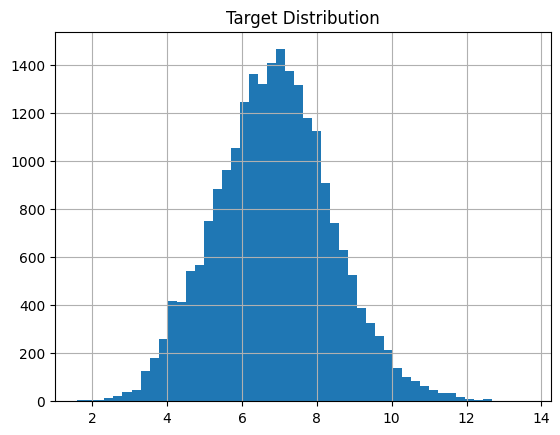

In [42]:
bought_1 = df_processed[df_processed['total_revenue'] > 0.0].copy() # All samples where bought == 1
bought_0 = df_processed[df_processed['total_revenue'] <= 0.0].copy() # All samples where bought == 0
#bought_0_known['industry'] = bought_0_known['industry'].astype('category')
#bought_0_known['in_stock'] = bought_0_known['in_stock'].astype('category')
#bought_0_known['discount_flag'] = bought_0_known['discount_flag'].astype('category')
#df_filtered = df_set_reduced[df_set_reduced['total_revenue'] > 0.0].copy()
print(len(bought_1))
print(len(bought_0))
y = np.log1p(bought_1[regressor_cols])
import matplotlib.pyplot as plt
y.hist(bins=50)
plt.title("Target Distribution")
plt.show()

0:	learn: 1.5194796	test: 1.5105069	best: 1.5105069 (0)	total: 20.9ms	remaining: 16.7s
100:	learn: 0.9797124	test: 0.9940512	best: 0.9940512 (100)	total: 1.1s	remaining: 7.64s
200:	learn: 0.9486097	test: 0.9801017	best: 0.9801017 (200)	total: 2.11s	remaining: 6.28s
300:	learn: 0.9266236	test: 0.9753256	best: 0.9753256 (300)	total: 3.1s	remaining: 5.14s
400:	learn: 0.9090947	test: 0.9726577	best: 0.9726362 (396)	total: 4.1s	remaining: 4.08s
500:	learn: 0.8929048	test: 0.9706953	best: 0.9706163 (498)	total: 5.34s	remaining: 3.19s
600:	learn: 0.8784893	test: 0.9704078	best: 0.9702688 (527)	total: 6.55s	remaining: 2.17s
Stopped by overfitting detector  (80 iterations wait)

bestTest = 0.9702688147
bestIteration = 527

Shrink model to first 528 iterations.
Original scale → RMSE: 77,792,012.54 | MAE: 2,524.11 | R^2: 0.6508 | MAPE: 180.58% | sMAPE: 74.30%


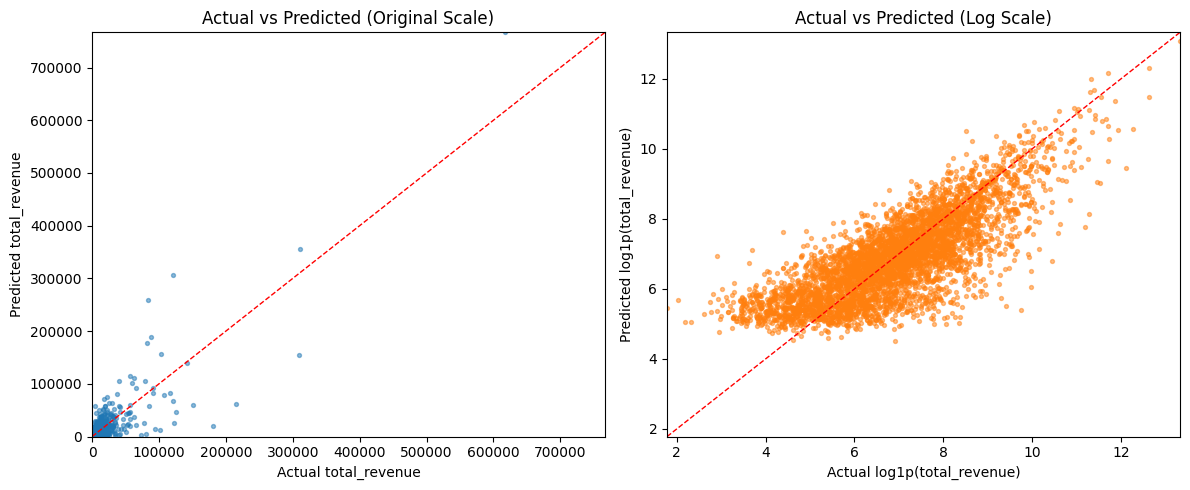

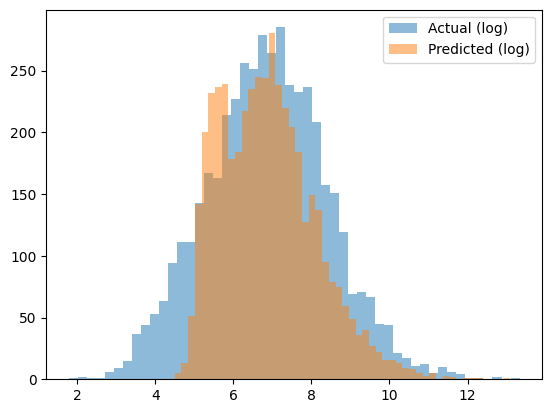

In [46]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


target = "total_revenue"

# 3) Build X and y (ensure target is numeric and non-negative for log1p)
#X = bought_1[cat_cols + continuous_cols].copy()
X = df_processed[[cat_cols + continuous_cols]]
y_raw = pd.to_numeric(bought_1[target], errors="coerce").fillna(0.0)

# Optional: if negatives can exist, clip to zero (or choose a different transform strategy)
y_raw = y_raw.clip(lower=0)


# 4) Log-transform the target
y_log = np.log1p(y_raw)

# 5) Split 80/20
X_train, X_val, y_train_log, y_val_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 6) Pools (pass categorical columns by name)
train_pool = Pool(X_train, y_train_log, cat_features=cat_cols)
val_pool   = Pool(X_val,   y_val_log,   cat_features=cat_cols)

# 7) Model
model_reg = CatBoostRegressor(
    iterations=800,
    learning_rate=0.06,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_state=42,
    verbose=100,
    early_stopping_rounds=80
)

model_reg.fit(train_pool, eval_set=val_pool)


preds_val_log = model_reg.predict(X_val)
preds_val = np.expm1(preds_val_log)
y_val = np.expm1(y_val_log)


apply_bias_correction = True
if apply_bias_correction:
    resid_log = y_val_log - preds_val_log
    sigma2 = np.var(resid_log[~np.isnan(resid_log)], ddof=1)  # unbiased estimate
    correction = np.exp(0.5 * sigma2)
    preds_val_bc = preds_val * correction
else:
    preds_val_bc = preds_val

# 10) Metrics on original scale
rmse = mean_squared_error(y_val, preds_val_bc)
mae  = mean_absolute_error(y_val, preds_val_bc)
r2   = r2_score(y_val, preds_val_bc)

# MAPE: protect against division by zero
with np.errstate(divide='ignore', invalid='ignore'):
    mape = np.mean(np.abs((y_val - preds_val_bc) / np.where(y_val == 0, np.nan, y_val))) * 100
mape = float(np.nan_to_num(mape, nan=np.inf))  # if many zeros, MAPE can be inf

# SMAPE is often more stable when zeros exist
smape = 100 * np.mean(
    2 * np.abs(preds_val_bc - y_val) / (np.abs(y_val) + np.abs(preds_val_bc) + 1e-12)
)

print(f"Original scale → RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R^2: {r2:.4f} | MAPE: {mape:.2f}% | sMAPE: {smape:.2f}%")

# 11) Quick diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Original scale
axes[0].scatter(y_val, preds_val_bc, s=8, alpha=0.5)
lims = [0, max(y_val.max(), preds_val_bc.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_title("Actual vs Predicted (Original Scale)")
axes[0].set_xlabel("Actual total_revenue"); axes[0].set_ylabel("Predicted total_revenue")

# (b) Log scale
axes[1].scatter(y_val_log, preds_val_log, s=8, alpha=0.5, color='tab:orange')
lims_log = [min(y_val_log.min(), preds_val_log.min()), max(y_val_log.max(), preds_val_log.max())]
axes[1].plot(lims_log, lims_log, 'r--', linewidth=1)
axes[1].set_xlim(lims_log); axes[1].set_ylim(lims_log)
axes[1].set_title("Actual vs Predicted (Log Scale)")
axes[1].set_xlabel("Actual log1p(total_revenue)"); axes[1].set_ylabel("Predicted log1p(total_revenue)")

plt.tight_layout()
plt.show()
plt.hist(y_val_log, bins=50, alpha=0.5, label="Actual (log)")

plt.hist(preds_val_log, bins=50, alpha=0.5, label="Predicted (log)")
plt.legend()
plt.show()

In [72]:
print(df_processed.columns)
df_processed[regressor_cols] = df_processed[regressor_cols].astype(float)

X = df_processed[all_cols].copy()
y_cls = (df_processed[["total_revenue"]] > 0).astype(int)
y_reg = pd.to_numeric(df_processed["total_revenue"], errors="coerce").fillna(0.0).clip(lower=0)
from IPython.display import display



print([df_processed[regressor_cols].columns])

Index(['industry', 'total_transactions', 'total_sessions',
       'order_history_page_views', 'products_pna_checked',
       'pna_availability_message_available_to_ship_on',
       'pna_availability_message_in_stock', 'pna_availability_message_from',
       'pna_availability_message_check_cart_for_availability',
       'pna_availability_message_estimated_to_ship_on',
       'pna_average_discount_percentage', 'pna_discount_percentage_0',
       'pna_discount_percentage_1to10', 'pna_discount_percentage_11to20',
       'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40',
       'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60',
       'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80',
       'pna_discount_percentage_81to90', 'pna_discount_percentage_90to99',
       'pna_lead_time_0', 'pna_lead_time_1to2', 'pna_lead_time_3to7',
       'pna_lead_time_8to14', 'pna_lead_time_15to30', 'pna_lead_time_31to59',
       'pna_lead_time_60andAbove', 't

In [78]:
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, mean_squared_error, mean_absolute_error, r2_score
)
import numpy as np
import pandas as pd

discounts = ["pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20", \
  "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50", "pna_discount_percentage_51to60", \
  "pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]

no_discount = ["pna_discount_percentage_0"]
#lead_times = ["pna_average_lead_time","pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_31to59","pna_lead_time_60andAbove"]

in_stock = ["pna_availability_message_from", "pna_availability_message_in_stock"]
not_in_stock = ["pna_availability_message_available_to_ship_on"]
stock_unavailable = ["pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on"]

lead_times = ["pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove"]
cat_cols = [['industry']+  ["discount_combo_2sets","set0_category"]][0]#discount_combo_2sets	set0_category

regressor_cols = ["total_revenue"]
label_cols = ["purchase"]

other_cont = ['total_sessions','order_history_page_views','total_transactions',"products_pna_checked","pna_average_discount_percentage","days_diff_session"]
continuous_cols = in_stock + not_in_stock+ stock_unavailable+ discounts  +lead_times + other_cont
all_cols = regressor_cols + cat_cols + continuous_cols
target = "purchase"

NEG_TO_POS_RATIO = 20     # downsample: keep at most 20x negatives per positive
RANDOM_STATE = 42
USE_BIAS_CORRECTION = True
SEARCH_THRESH_GRID = np.linspace(0.01, 0.80, 40)
#bought_0 = bought_0.copy()
#bought_1 = bought_1.copy()

#bought_0[target] = 0.0
full = df_processed.copy()
full[target] = pd.to_numeric(full[target], errors="coerce").fillna(0.0).clip(lower=0)


#full = pd.concat([bought_0, bought_1], ignore_index=True)

all_cols = cat_cols + continuous_cols
missing = set(all_cols) - set(full.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

X = full[all_cols].copy()
y_cls = (full[["total_revenue"]] > 0).astype(int)
y_reg = pd.to_numeric(full["total_revenue"], errors="coerce").fillna(0.0).clip(lower=0)


def downsample_negatives(X, y_cls, y_reg, neg_to_pos_ratio=20, random_state=42):
    rng = np.random.default_rng(random_state)
    pos_idx = np.where(y_cls == 1)[0]
    neg_idx = np.where(y_cls == 0)[0]
    n_pos = len(pos_idx)
    n_neg_keep = min(len(neg_idx), neg_to_pos_ratio * max(n_pos, 1))
    keep_neg_idx = rng.choice(neg_idx, size=n_neg_keep, replace=False) if n_neg_keep > 0 else np.array([], dtype=int)
    keep_idx = np.concatenate([pos_idx, keep_neg_idx])
    return X.iloc[keep_idx], y_cls.iloc[keep_idx], y_reg.iloc[keep_idx]

X_ds, y_cls_ds, y_reg_ds = downsample_negatives(X, y_cls, y_reg, NEG_TO_POS_RATIO, RANDOM_STATE)

X_train, X_val, y_train_cls, y_val_cls, y_train_reg, y_val_reg = train_test_split(
    X_ds, y_cls_ds, y_reg_ds, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls_ds
)

##print(y_cls.shape)
#pos_ratio_full = (y_cls == 1).mean()
##print(pos_ratio_full.shape)
#w = (1.0 - pos_ratio_full) / (pos_ratio_full + 1e-12)
##print(w.shape)
#class_weights = [1.0, (1.0 - pos_ratio_full) / (pos_ratio_full + 1e-12)]
#print(class_weights[1])
#class_weights = [1.0, w]
#print(class_weights[1])
# Example: y_train is 0/1
pos_ratio_full = float(y_train_cls.mean())  # ensure scalar
w_pos = (1.0 - pos_ratio_full) / (pos_ratio_full + 1e-12)  # relative to w_neg = 1.0

class_weights = [1.0, float(w_pos)]  # NOT a string, and not a nested list



# 7) Stage 1 — Classifier on positives
clf = CatBoostClassifier(
    iterations=1200,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_state=RANDOM_STATE,
    verbose=100,
    early_stopping_rounds=120,
    class_weights=class_weights
)

clf.fit(
    Pool(X_train, y_train_cls, cat_features=cat_cols),
    eval_set=Pool(X_val, y_val_cls, cat_features=cat_cols)
)

p_pos = clf.predict_proba(X_val)[:, 1]
try:
    auc = roc_auc_score(y_val_cls, p_pos)
    print(f"[Stage 1: Classifier] AUC: {auc:.4f}")
except Exception as e:
    print("[Stage 1: Classifier] AUC not available:", e)

# 8) Stage 2 — Regressor on positives, with log target
pos_train_mask = (y_train_reg > 0)
X_train_pos = X_train[pos_train_mask]
y_train_pos_log = np.log1p(y_train_reg[pos_train_mask])

# Positive subset on validation (for eval & bias correction)
pos_val_mask = (y_val_reg > 0)
X_val_pos = X_val[pos_val_mask]
y_val_pos_log = np.log1p(y_val_reg[pos_val_mask])

regr = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_state=RANDOM_STATE,
    verbose=100,
    early_stopping_rounds=150,
    l2_leaf_reg=6.0
)

regr.fit(
    Pool(X_train_pos, y_train_pos_log, cat_features=cat_cols),
    eval_set=Pool(X_val_pos, y_val_pos_log, cat_features=cat_cols)
)

yhat_pos_log = regr.predict(X_val)
yhat_pos = np.expm1(yhat_pos_log)
if USE_BIAS_CORRECTION and pos_val_mask.any():
    resid_log = y_val_pos_log - regr.predict(X_val_pos)
    sigma2 = np.var(resid_log[~np.isnan(resid_log)], ddof=1)
    bc = float(np.exp(0.5 * sigma2))
else:
    bc = 1.0

yhat_pos_bc = yhat_pos * bc

y_pred_expected = p_pos * yhat_pos_bc


def evaluate_threshold_grid(y_true, yhat_pos_bc, p_pos, grid):
    best = None
    for t in grid:
        y_pred = np.where(p_pos >= t, yhat_pos_bc, 0.0)
        rmse = mean_squared_error(y_true, y_pred)# squared=False)
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        if (best is None) or (rmse < best['rmse']):
            best = {'t': float(t), 'rmse': rmse, 'mae': mae, 'r2': r2}
    return best

best_thresh = evaluate_threshold_grid(y_val_reg.values, yhat_pos_bc, p_pos, SEARCH_THRESH_GRID)
y_pred_thresh = np.where(p_pos >= best_thresh['t'], yhat_pos_bc, 0.0)


def report_metrics(name, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred)#, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    mape = float(np.nan_to_num(mape, nan=np.inf))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-12))
    print(f"{name:>24} → RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R^2: {r2:.4f} | MAPE: {mape:.2f}% | sMAPE: {smape:.2f}%")

# Baselines
y_zero = np.zeros_like(y_val_reg)
y_mean = np.full_like(y_val_reg, fill_value=y_train_reg.mean(), dtype=float)

print("\n=== Baselines ===")
report_metrics("Always Zero", y_val_reg, y_zero)
report_metrics("Global Mean", y_val_reg, y_mean)

print("\n=== Two-Stage Results ===")
report_metrics("Expected Value (p * y+)", y_val_reg, y_pred_expected)
print(f"Best threshold for RMSE: t = {best_thresh['t']:.3f}")
report_metrics("Thresholded (best t)",   y_val_reg, y_pred_thresh)

0:	test: 1.0000000	best: 1.0000000 (0)	total: 82.3ms	remaining: 1m 38s
100:	test: 1.0000000	best: 1.0000000 (0)	total: 5.99s	remaining: 1m 5s
Stopped by overfitting detector  (120 iterations wait)

bestTest = 1
bestIteration = 0

Shrink model to first 1 iterations.
[Stage 1: Classifier] AUC: 1.0000
0:	learn: 1.5250970	test: 1.5226449	best: 1.5226449 (0)	total: 11.4ms	remaining: 17s
100:	learn: 0.9815903	test: 1.0210405	best: 1.0210405 (100)	total: 1.02s	remaining: 14.1s
200:	learn: 0.9574864	test: 1.0083424	best: 1.0083424 (200)	total: 2.03s	remaining: 13.1s
300:	learn: 0.9374473	test: 1.0012299	best: 1.0012299 (300)	total: 3s	remaining: 11.9s
400:	learn: 0.9265008	test: 0.9992973	best: 0.9992435 (395)	total: 3.93s	remaining: 10.8s
500:	learn: 0.9156584	test: 0.9968300	best: 0.9968300 (500)	total: 4.88s	remaining: 9.73s
600:	learn: 0.9049804	test: 0.9950782	best: 0.9950782 (600)	total: 5.86s	remaining: 8.77s
700:	learn: 0.8953247	test: 0.9937388	best: 0.9937261 (699)	total: 6.84s	remai

In [117]:
effect_revenue = 21.4
ASSUMED_MARGIN = 0.30
effect_profit = effect_revenue * ASSUMED_MARGIN

print("Revenue effect:", effect_revenue)
print("Profit effect:", effect_profit)


Revenue effect: 21.4
Profit effect: 6.419999999999999


model prepared
permutation importance
['industry', 'discount_combo_2sets', 'set0_category', 'pna_discount_percentage_0', 'pna_discount_percentage_1to10', 'pna_discount_percentage_11to20', 'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40', 'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60', 'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80', 'pna_discount_percentage_81to90', 'pna_discount_percentage_90to99', 'pna_availability_message_from', 'pna_availability_message_in_stock', 'pna_availability_message_available_to_ship_on', 'pna_availability_message_check_cart_for_availability', 'pna_availability_message_estimated_to_ship_on', 'pna_availability_message_check_cart_for_availability', 'pna_availability_message_estimated_to_ship_on', 'pna_lead_time_0', 'pna_lead_time_1to2', 'pna_lead_time_3to7', 'pna_lead_time_8to14', 'pna_lead_time_15to30', 'pna_lead_time_31to59', 'pna_lead_time_60andAbove', 'total_sessions', 'order_history_page_views', 'to

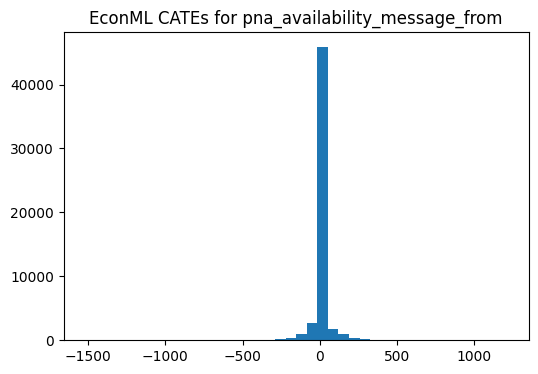


EconML CATE summary for pna_availability_message_in_stock: mean=27.7815, sd=68.3771


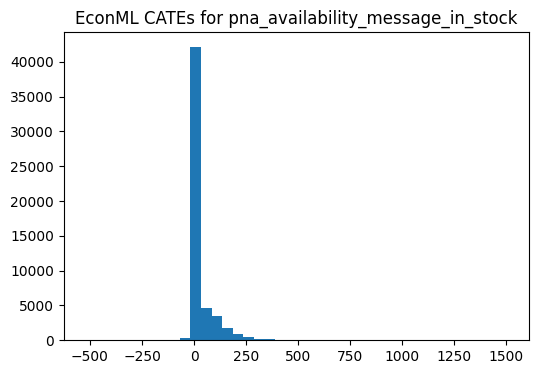


EconML CATE summary for pna_availability_message_available_to_ship_on: mean=19.8563, sd=73.1146


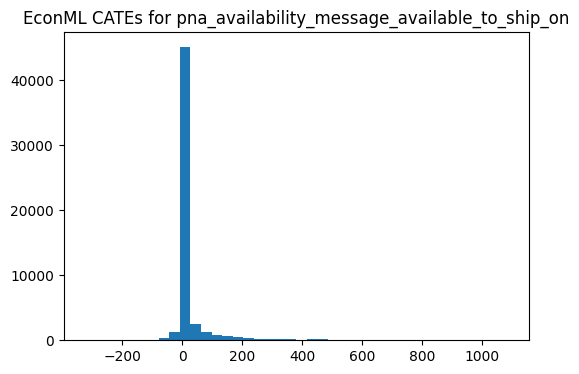


EconML CATE summary for pna_availability_message_check_cart_for_availability: mean=-26.5137, sd=860.7298


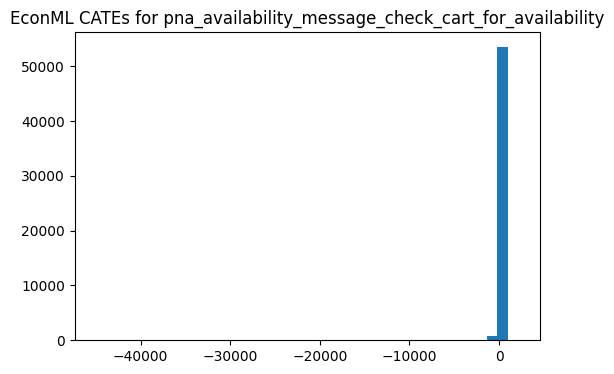


EconML CATE summary for pna_availability_message_estimated_to_ship_on: mean=-1.0033, sd=76.5707


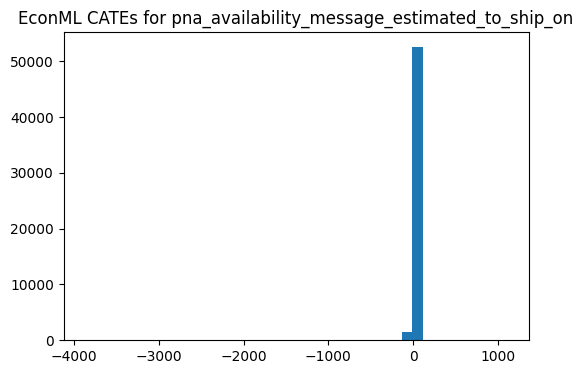

In [113]:
# discount_analysis_pipeline.py
"""
Unified discount-effects analysis pipeline.

Assumptions:
- Your trained CatBoostRegressor object is available as `ctr` (pass it in).
- Target column name is "total_revenue".
- You provide lists: cat_cols (categorical), cont_cols (continuous; includes discount_cols), discount_cols (subset).
- The DataFrame passed may contain extra columns; they'll be dropped for modeling/prediction.
- If expected feature columns are missing, an informative error is raised.

Provides:
- prepare_model_df(...) : ensures correct columns
- permutation importance
- SHAP (explainer, shap_values) + plotting utilities
- average marginal effects (finite diff)
- scenario simulation (revenue + profit under margin assumption)
- econml CausalForestDML per discount column (CATEs)
- DoWhy backdoor identification + linear regression + simple refutation
- run_pipeline(...) and run_pipeline_and_plot(...) orchestration functions
"""

import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV

import shap

# econml & dowhy (make sure installed in your env)
from econml.dml import CausalForestDML
from dowhy import CausalModel

# ---------- CONFIG ----------
TARGET_COL = "total_revenue"
DEFAULT_MARGIN = 0.30 # profit = margin * predicted revenue by default
discount_cols = ["pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20", \
  "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50", "pna_discount_percentage_51to60", \
  "pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]
in_stock = ["pna_availability_message_from", "pna_availability_message_in_stock"]
not_in_stock = ["pna_availability_message_available_to_ship_on"]
stock_unavailable = ["pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on"]

stock_variables = in_stock + not_in_stock + stock_unavailable

# ---------- UTILITIES ----------
def prepare_model_df(df: pd.DataFrame, cat_cols, cont_cols, target_col=TARGET_COL):
    """
    Return df_model (subset) and features list.
    Drops any extra columns not used by model. Raises if any expected feature or target is missing.
    """
    cat_cols = list(cat_cols)
    cont_cols = list(cont_cols)
    features = cat_cols + cont_cols
    missing = [c for c in features if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected model feature columns: {missing}")
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in dataframe.")
    df_model = df[features + [target_col]].copy()
    return df_model, features

# ---------- PERMUTATION IMPORTANCE ----------
def compute_permutation_importance(model, df_model, features, target_col=TARGET_COL, n_repeats=5):
    #print(features)
    X = df_model[features]
    y = df_model[target_col].values
    print("compute permutaion")
    res = permutation_importance(model, X, y, n_repeats=n_repeats, random_state=0,
                                 scoring="neg_mean_squared_error")
    print("compute permutaion - don")
    imp_df = pd.DataFrame({
        "feature": features,
        "imp_mean": res.importances_mean,
        "imp_std": res.importances_std
    }).sort_values("imp_mean", ascending=False).reset_index(drop=True)
    print(imp_df)
    return imp_df

# ---------- SHAP ----------
def shap_analysis(model, df_model, features, sample_size=2000, random_state=0):
    X = df_model[features]
    X_sample = X.sample(sample_size, random_state=random_state) if len(X) > sample_size else X.copy()
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    shap_abs_mean = pd.DataFrame(np.abs(shap_values), columns=X_sample.columns).mean().reset_index()
    shap_abs_mean.columns = ["feature", "mean_abs_shap"]
    shap_abs_mean = shap_abs_mean.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    return explainer, X_sample, shap_values, shap_abs_mean

# SHAP plotting helpers
def plot_shap_summary(explainer, X_sample, shap_values, max_display=20):
    shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=max_display, show=False)
    plt.title("Global SHAP feature importance")
    plt.tight_layout(); plt.show()
    shap.summary_plot(shap_values, X_sample, max_display=max_display, show=False)
    plt.title("SHAP beeswarm")
    plt.tight_layout(); plt.show()

def plot_shap_dependence_cols(shap_values, X_sample, cols):
    for col in cols:
        try:
            shap.dependence_plot(col, shap_values, X_sample, show=False)
            plt.title(f"SHAP dependence: {col}")
            plt.tight_layout(); plt.show()
        except Exception as e:
            print(f"Could not plot dependence for {col}: {e}")

# ---------- AVERAGE MARGINAL EFFECT (finite diff) ----------
def average_marginal_effect(model, df_model, features_of_interest, delta=1.0):
    X = df_model[[c for c in df_model.columns if c != TARGET_COL]].copy()
    base_pred = model.predict(X)
    rows = []
    for feat in features_of_interest:
        if feat not in X.columns:
            raise ValueError(f"{feat} not in model features")
        X2 = X.copy()
        X2[feat] = X2[feat] + delta
        new_pred = model.predict(X2)
        diff = new_pred - base_pred
        rows.append({
            "feature": feat,
            "ame_per_unit": float(np.mean(diff)),
            "ame_std": float(np.std(diff)),
            "ame_median": float(np.median(diff))
        })
    return pd.DataFrame(rows).sort_values("ame_per_unit", ascending=False).reset_index(drop=True)

# ---------- SCENARIO SIMULATION ----------
def simulate_scenario(model, df_model, features, change_spec: dict, margin=DEFAULT_MARGIN):
    """
    change_spec: dict of {feature: delta} (delta can be positive or negative)
    Returns: revenue_delta, revenue_pct, profit_delta, per_row_delta (np.array)
    """
    X = df_model[features].copy()
    base_pred = model.predict(X)
    base_profit = base_pred * margin

    X_new = X.copy()
    for c, delta in change_spec.items():
        if c not in X_new.columns:
            raise ValueError(f"Feature '{c}' not present in model features.")
        X_new[c] = (X_new[c] + delta).clip(lower=0)

    new_pred = model.predict(X_new)
    new_profit = new_pred * margin

    return {
        "revenue_delta": float(new_pred.sum() - base_pred.sum()),
        "revenue_pct": float(new_pred.sum() / base_pred.sum() - 1) if base_pred.sum() != 0 else np.nan,
        "profit_delta": float(new_profit.sum() - base_profit.sum()),
        "per_row_delta": new_pred - base_pred
    }

def plot_scenarios(results_dict):
    """
    results_dict: {scenario_name: {"revenue_delta":..., "profit_delta":..., "revenue_pct":...}}
    """
    df = pd.DataFrame(results_dict).T
    if df.empty:
        print("No scenarios to plot.")
        return df
    df[["revenue_delta", "profit_delta"]].plot.bar(rot=45, figsize=(8,4))
    plt.ylabel("Absolute delta")
    plt.title("Scenario revenue & profit deltas")
    plt.tight_layout(); plt.show()
    print("\nScenario results (rounded):")
    print(df.round(2))
    return df

# ---------- ECONML: CausalForestDML ----------
def _prepare_controls_for_econml(df_model, cat_cols, cont_cols, treat_col, sample_frac=None, random_state=0):
    """
    Build X (controls), T (treatment), Y (outcome).
    One-hot encode categorical controls.
    """
    # features excluding treat
    features = [c for c in list(cat_cols) + list(cont_cols) if c != treat_col]
    df_controls = df_model[features].copy()

    # one-hot cat cols
    cat_present = [c for c in cat_cols if c in df_controls.columns]
    df_cat = pd.get_dummies(df_controls[cat_present].astype(str), drop_first=True) if cat_present else pd.DataFrame(index=df_controls.index)

    cont_present = [c for c in cont_cols if (c in df_controls.columns) and (c not in cat_cols)]
    df_cont = df_controls[cont_present].copy() if cont_present else pd.DataFrame(index=df_controls.index)

    X = pd.concat([df_cont.reset_index(drop=True), df_cat.reset_index(drop=True)], axis=1)
    T = df_model[treat_col].values.reshape(-1, 1)
    Y = df_model[TARGET_COL].values

    if sample_frac and 0 < sample_frac < 1:
        idx = df_model.sample(frac=sample_frac, random_state=random_state).index
        X = X.loc[idx].reset_index(drop=True)
        T = T[idx]
        Y = Y[idx]
    return X, T, Y

def econml_causal_forest(df_model, cat_cols, cont_cols, treat_col, sample_frac=0.4, random_state=0):
    """
    Fit CausalForestDML to estimate per-row CATEs of treat_col on TARGET_COL.
    Returns (cate_array, fitted_estimator).
    """
    X, T, Y = _prepare_controls_for_econml(df_model, cat_cols, cont_cols, treat_col, sample_frac=sample_frac, random_state=random_state)
    # learners
    model_y = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=random_state)
    model_t = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=random_state)
    est = CausalForestDML(model_y=model_y, model_t=model_t, discrete_treatment=False, random_state=random_state)
    est.fit(Y, T, X=X.values)
    cate = est.effect(X.values)
    return cate, est

# ---------- DoWhy backdoor linear ----------
def dowhy_backdoor_linear(df_model, treatment_col, common_causes):
    """
    Build DoWhy causal model and estimate via backdoor.linear_regression.
    Returns (identified_estimand, estimate, refute_result).
    """
    # Build model with selected common causes
    model = CausalModel(data=df_model, treatment=treatment_col, outcome=TARGET_COL, common_causes=common_causes)
    identified_estimand = model.identify_effect()
    estimate = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression")
    # simple refutation: random_common_cause
    refute = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
    return identified_estimand, estimate, refute

# ---------- ORCHESTRATOR ----------
def run_pipeline(df, ctr, cat_cols, cont_cols, discount_cols,
                 shap_sample_size=2000,
                 run_econml=True, econml_sample_frac=0.4,
                 run_dowhy=True):
    """
    Run the full analysis and return a results dict.
    """
    # 1) prepare model df (drops extra cols; raises if missing)
    df_model, features = prepare_model_df(df, cat_cols, cont_cols, target_col=TARGET_COL)
    print("model prepared")
    results = {}
    results['features'] = features

    print("permutation importance")
    try:
        results['perm_imp'] = compute_permutation_importance(ctr, df_model, features)
    except Exception as e:
        results['perm_imp_error'] = str(e)

    print("SHAP")
    try:
        explainer, X_sample, shap_values, shap_summary = shap_analysis(ctr, df_model, features, sample_size=shap_sample_size)
        results['shap'] = {
            "explainer": explainer,
            "X_sample": X_sample,
            "shap_values": shap_values,
            "shap_summary_df": shap_summary
        }
    except Exception as e:
        results['shap_error'] = str(e)

    print("AME")
    try:
        results['ame'] = average_marginal_effect(ctr, df_model, discount_cols, delta=1.0)
    except Exception as e:
        results['ame_error'] = str(e)

    print("sceneraio errors")

    try:
        scenario_results = {}
        for d in discount_cols:
            scenario_results[f"+10_{d}"] = simulate_scenario(ctr, df_model, features, {d: 10})
        results['scenarios'] = scenario_results
    except Exception as e:
        results['scenarios_error'] = str(e)

    # 6) econml per discount col
    print("econml per dicount col")
    results['econml'] = {}
    if run_econml:
        for d in stock_variables:#variables considered
            try:
                cate, est = econml_causal_forest(df_model, cat_cols, stock_variables, d, sample_frac=econml_sample_frac)
                results['econml'][d] = {"cate": cate, "estimator": est}
            except Exception as e:
                results['econml'][d] = {"error": str(e)}

    print("dowhy")
    results['dowhy'] = {}
    if run_dowhy:
        try:
            top_feats = list(results.get('perm_imp', pd.DataFrame()).feature.head(20))
            if len(top_feats) == 0:
                top_feats = [f for f in features if f not in discount_cols][:20]
            for d in discount_cols:
                common_causes = [f for f in top_feats if f != d]
                ident, estimate, refute = dowhy_backdoor_linear(df_model, d, common_causes)
                results['dowhy'][d] = {"ident": ident, "estimate": estimate, "refute": refute}
        except Exception as e:
            results['dowhy_error'] = str(e)

    return results

# ---------- PLOTTING DRIVER ----------
def run_pipeline_and_plot(df, ctr, cat_cols, cont_cols, discount_cols,
                          shap_sample_size=2000,
                          run_econml=True, econml_sample_frac=0.4, run_dowhy=True):
    """
    Runs run_pipeline(...) and then produces SHAP plots, scenario bar charts,
    econml CATE histograms, and prints DoWhy outputs.
    """
    results = run_pipeline(df, ctr, cat_cols, cont_cols, discount_cols,
                           shap_sample_size=shap_sample_size,
                           run_econml=run_econml, econml_sample_frac=econml_sample_frac,
                           run_dowhy=run_dowhy)

    # SHAP plots
    if 'shap' in results:
        shap_info = results['shap']
        explainer = shap_info['explainer']
        X_sample = shap_info['X_sample']
        shap_values = shap_info['shap_values']
        shap_summary_df = shap_info['shap_summary_df']
        print("\nTop SHAP features:\n", shap_summary_df.head(20))
        plot_shap_summary(explainer, X_sample, shap_values, max_display=20)
        # dependence for discount cols (first up to 4)
        plot_shap_dependence_cols(shap_values, X_sample, discount_cols[:4])

    # Scenario plots
    if 'scenarios' in results:
        print("\nPlotting scenario results...")
        plot_scenarios(results['scenarios'])

    # econml CATE histograms
    if 'econml' in results:
        for d, info in results['econml'].items():
            if 'cate' in info:
                cate = info['cate']
                print(f"\nEconML CATE summary for {d}: mean={np.mean(cate):.4f}, sd={np.std(cate):.4f}")
                plt.figure(figsize=(6,4)); plt.hist(cate, bins=40); plt.title(f"EconML CATEs for {d}"); plt.show()
            else:
                print(f"\nEconML for {d} error:", info.get('error'))

    # DoWhy outputs
    if 'dowhy' in results:
        for d, info in results['dowhy'].items():
            if 'estimate' in info:
                print(f"\nDoWhy estimate for {d}:")
                try:
                    print(info['estimate'])
                    print("Refutation result:")
                    print(info['refute'])
                except Exception as e:
                    print("Could not print DoWhy output:", e)
            else:
                if isinstance(info, dict) and 'error' in info:
                    print(f"\nDoWhy error for {d}: {info['error']}")

    return results
discount_cols = ["pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20", \
  "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50", "pna_discount_percentage_51to60", \
  "pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]

other_cont = ['total_sessions','order_history_page_views','total_transactions',"products_pna_checked","pna_average_discount_percentage","days_diff_session"]
in_stock = ["pna_availability_message_from", "pna_availability_message_in_stock"]
not_in_stock = ["pna_availability_message_available_to_ship_on"]
stock_unavailable = ["pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on"]



lead_times = ["pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove"]
other_cont = ['total_sessions','order_history_page_views','total_transactions',"products_pna_checked","pna_average_discount_percentage","days_diff_session"]
cat_cols = ["industry","discount_combo_2sets","set0_category"]

cont_cols = discount_cols + in_stock + not_in_stock + stock_unavailable + stock_unavailable + lead_times+other_cont

#from discount_analysis_pipeline import run_pipeline_and_plot
results_stock = run_pipeline_and_plot(full, regr, cat_cols, cont_cols, discount_cols)
#

In [110]:
from IPython.display import display
display(results_stock)

{'features': ['industry',
  'discount_combo_2sets',
  'set0_category',
  'pna_discount_percentage_0',
  'pna_discount_percentage_1to10',
  'pna_discount_percentage_11to20',
  'pna_discount_percentage_21to30',
  'pna_discount_percentage_31to40',
  'pna_discount_percentage_41to50',
  'pna_discount_percentage_51to60',
  'pna_discount_percentage_61to70',
  'pna_discount_percentage_71to80',
  'pna_discount_percentage_81to90',
  'pna_discount_percentage_90to99',
  'pna_availability_message_from',
  'pna_availability_message_in_stock',
  'pna_availability_message_available_to_ship_on',
  'pna_availability_message_check_cart_for_availability',
  'pna_availability_message_estimated_to_ship_on',
  'pna_availability_message_check_cart_for_availability',
  'pna_availability_message_estimated_to_ship_on',
  'pna_lead_time_0',
  'pna_lead_time_1to2',
  'pna_lead_time_3to7',
  'pna_lead_time_8to14',
  'pna_lead_time_15to30',
  'pna_lead_time_31to59',
  'pna_lead_time_60andAbove',
  'total_sessions',


In [87]:
discounts = ["pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20", \
  "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50", "pna_discount_percentage_51to60", \
  "pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]

no_discount = ["pna_discount_percentage_0"]
#lead_times = ["pna_average_lead_time","pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_31to59","pna_lead_time_60andAbove"]

in_stock = ["pna_availability_message_from", "pna_availability_message_in_stock"]
not_in_stock = ["pna_availability_message_available_to_ship_on"]
stock_unavailable = ["pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on"]

lead_times = ["pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove"]
cat_cols = [['industry']+  ["discount_combo_2sets","set0_category"]][0]#discount_combo_2sets	set0_category

regressor_cols = ["total_revenue"]
label_cols = ["purchase"]
other_cont = ['total_sessions','order_history_page_views','total_transactions',"products_pna_checked","pna_average_discount_percentage","days_diff_session"]
continuous_cols = in_stock + not_in_stock+ stock_unavailable+ discounts +  no_discount +lead_times +other_cont

#'pna_average_discount_percentage', 'days_diff_transaction', 'days_diff_session', 'pna_lead_time_15to30
all_cols = cat_cols + continuous_cols + regressor_cols + label_cols
print(cat_cols)
print(discounts)
print(no_discount)
print(continuous_cols)
print(len(all_cols))
#print(all_cols)

['industry', 'discount_combo_2sets', 'set0_category']
['pna_discount_percentage_0', 'pna_discount_percentage_1to10', 'pna_discount_percentage_11to20', 'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40', 'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60', 'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80', 'pna_discount_percentage_81to90', 'pna_discount_percentage_90to99']
['pna_discount_percentage_0']
['pna_availability_message_from', 'pna_availability_message_in_stock', 'pna_availability_message_available_to_ship_on', 'pna_availability_message_check_cart_for_availability', 'pna_availability_message_estimated_to_ship_on', 'pna_discount_percentage_0', 'pna_discount_percentage_1to10', 'pna_discount_percentage_11to20', 'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40', 'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60', 'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80', 'pna_discount_percenta

In [107]:
# Keep the first occurrence; drop later duplicates for any duplicated name
import numpy as np


full_ = full.copy()
name = "pna_availability_message_available_to_ship_on"  # <-- make sure this is the exact duplicate name
# (Optional) normalize whitespace—helps if there are invisible spaces
full_.columns = full_.columns.map(lambda c: c.strip() if isinstance(c, str) else c)

# If you might have a MultiIndex, check first
if isinstance(full_.columns, pd.MultiIndex):
    # Example: duplicate is in the last level of the MultiIndex
    positions = [i for i, tpl in enumerate(full_.columns) if tpl[-1] == name]
else:
    positions = np.where(full_.columns.to_numpy() == name)[0].tolist()

print("Positions for the name:", positions)
print("Count before:", (full_.columns == name).sum() if not isinstance(full_.columns, pd.MultiIndex) else "N/A (MultiIndex)")

# Drop exactly the second occurrence (change the index you want to drop)
if len(positions) >= 2:
    j = positions[1]  # drop the 2nd one; use positions[0] to drop the 1st, etc.
    keep_idx = [i for i in range(full_.shape[1]) if i != j]
    full_ = full_.iloc[:, keep_idx]
else:
    print(f"No duplicate found for: {name!r}. Nothing dropped.")

# Verify
if not isinstance(full_.columns, pd.MultiIndex):
    print("Count after:", (full_.columns == name).sum())
print(full_.columns)



Positions for the name: [5]
Count before: 1
No duplicate found for: 'pna_availability_message_available_to_ship_on'. Nothing dropped.
Count after: 1
Index(['industry', 'total_transactions', 'total_sessions',
       'order_history_page_views', 'products_pna_checked',
       'pna_availability_message_available_to_ship_on',
       'pna_availability_message_in_stock', 'pna_availability_message_from',
       'pna_availability_message_check_cart_for_availability',
       'pna_availability_message_estimated_to_ship_on',
       'pna_average_discount_percentage', 'pna_discount_percentage_0',
       'pna_discount_percentage_1to10', 'pna_discount_percentage_11to20',
       'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40',
       'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60',
       'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80',
       'pna_discount_percentage_81to90', 'pna_discount_percentage_90to99',
       'pna_lead_time_0', 'pna_lead_

In [108]:
import unicodedata

def norm(s):
    if isinstance(s, str):
        s = unicodedata.normalize("NFKC", s)  # unify Unicode
        s = s.replace("\u200b", "")           # remove zero-width space
        s = s.strip()                         # trim whitespace
    return s

normed_cols = pd.Index([norm(c) for c in full_.columns])
dupes_after_norm = normed_cols[normed_cols.duplicated(keep=False)]
print("Duplicated after normalization:", dupes_after_norm.tolist())


Duplicated after normalization: []


In [111]:
import numpy as np
import pandas as pd

def _class_name(obj):
    try:
        return obj.__class__.__name__
    except Exception:
        return type(obj).__name__

def summarize_econml_output(results, quantiles=(.1, .25, .5, .75, .9)):
    econ = results.get('econml', {}) or {}
    rows = []
    for var, payload in econ.items():
        cate = np.asarray(payload.get('cate'))
        if cate.ndim > 1:
            cate = cate.ravel()
        mask = ~np.isnan(cate)
        if mask.any():
            qs = np.quantile(cate[mask], quantiles)
        else:
            qs = [np.nan] * len(quantiles)
        rows.append({
            'variable': var,
            'n': int(cate.size),
            'n_nan': int(np.isnan(cate).sum()),
            'mean': float(np.nanmean(cate)) if cate.size else np.nan,
            'std': float(np.nanstd(cate)) if cate.size else np.nan,
            'min': float(np.nanmin(cate)) if cate.size else np.nan,
            **{f"q{int(q*100)}": float(v) for q, v in zip(quantiles, qs)},
            'max': float(np.nanmax(cate)) if cate.size else np.nan,
            'estimator': _class_name(payload.get('estimator'))
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(by='mean', ascending=True, ignore_index=True)
    return df

# Example: `results` is your dictionary from the run
summary_df = summarize_econml_output(results)

# Display compact, readable table
with pd.option_context('display.float_format', '{:,.3f}'.format,
                       'display.max_rows', 200,
                       'display.max_colwidth', None):
    display(summary_df)


,variable,n,n_nan,mean,std,min,q10,q25,q50,q75,q90,max,estimator
0,pna_discount_percentage_71to80,54425,0,-7.105,"3,565.617","-237,668.376",-717.804,-85.498,-1.868,130.228,997.888,"56,595.717",CausalForestDML
1,pna_discount_percentage_0,54425,0,10.695,31.025,-480.060,-0.003,0.089,0.347,0.721,38.754,440.371,CausalForestDML
2,pna_discount_percentage_21to30,54425,0,16.220,162.673,"-1,961.177",-16.659,-0.562,0.516,8.689,52.328,"1,940.187",CausalForestDML
3,pna_discount_percentage_1to10,54425,0,21.409,125.721,"-1,957.556",-4.868,-0.682,0.860,19.701,87.237,"2,681.568",CausalForestDML
4,pna_discount_percentage_41to50,54425,0,44.410,688.374,"-13,395.011",-246.686,-18.868,20.748,108.489,441.101,"22,554.979",CausalForestDML
5,pna_discount_percentage_11to20,54425,0,72.872,163.341,"-1,319.873",-68.004,-0.231,15.331,117.065,304.208,"2,258.558",CausalForestDML
6,pna_discount_percentage_31to40,54425,0,134.536,"1,181.359","-12,736.307",-253.703,-68.854,16.212,167.749,537.426,"21,793.033",CausalForestDML
7,pna_discount_percentage_51to60,54425,0,155.581,"1,507.480","-26,522.651",-169.111,-42.939,3.386,190.804,780.275,"20,899.665",CausalForestDML
8,pna_discount_percentage_61to70,54425,0,180.270,"1,355.769","-101,967.148",-263.542,-12.395,55.127,333.143,784.063,"47,258.841",CausalForestDML
9,pna_discount_percentage_81to90,54425,0,283.511,"1,764.573","-84,407.197",-401.349,-186.259,19.538,239.794,"1,867.032","111,587.712",CausalForestDML


In [114]:
def _class_name(obj):
    try:
        return obj.__class__.__name__
    except Exception:
        return type(obj).__name__

def summarize_econml_output(results, quantiles=(.1, .25, .5, .75, .9)):
    econ = results.get('econml', {}) or {}
    rows = []
    for var, payload in econ.items():
        cate = np.asarray(payload.get('cate'))
        if cate.ndim > 1:
            cate = cate.ravel()
        mask = ~np.isnan(cate)
        if mask.any():
            qs = np.quantile(cate[mask], quantiles)
        else:
            qs = [np.nan] * len(quantiles)
        rows.append({
            'variable': var,
            'n': int(cate.size),
            'n_nan': int(np.isnan(cate).sum()),
            'mean': float(np.nanmean(cate)) if cate.size else np.nan,
            'std': float(np.nanstd(cate)) if cate.size else np.nan,
            'min': float(np.nanmin(cate)) if cate.size else np.nan,
            **{f"q{int(q*100)}": float(v) for q, v in zip(quantiles, qs)},
            'max': float(np.nanmax(cate)) if cate.size else np.nan,
            'estimator': _class_name(payload.get('estimator'))
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(by='mean', ascending=True, ignore_index=True)
    return df

# Example: `results` is your dictionary from the run
summary_df = summarize_econml_output(results_stock)

# Display compact, readable table
with pd.option_context('display.float_format', '{:,.3f}'.format,
                       'display.max_rows', 200,
                       'display.max_colwidth', None):
    display(summary_df)

,variable,n,n_nan,mean,std,min,q10,q25,q50,q75,q90,max,estimator
0,pna_availability_message_check_cart_for_availability,54425,0,-26.514,860.730,"-45,004.733",-7.329,-0.046,0.001,0.123,14.377,"2,176.461",CausalForestDML
1,pna_availability_message_estimated_to_ship_on,54425,0,-1.003,76.571,"-3,871.206",-0.876,-0.006,-0.000,0.005,2.838,"1,110.290",CausalForestDML
2,pna_availability_message_from,54425,0,9.417,97.303,"-1,521.170",-6.012,-0.011,0.000,0.099,28.957,"1,214.301",CausalForestDML
3,pna_availability_message_available_to_ship_on,54425,0,19.856,73.115,-325.305,-0.522,-0.011,0.035,1.211,52.310,"1,085.819",CausalForestDML
4,pna_availability_message_in_stock,54425,0,27.782,68.377,-524.868,-0.305,0.000,0.139,13.277,105.857,"1,504.689",CausalForestDML


from matplotlib import pyplot as plt
summary_df['mean'].plot(kind='hist', bins=20, title='mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
summary_df['std'].plot(kind='hist', bins=20, title='std')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
summary_df['min'].plot(kind='hist', bins=20, title='min')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
summary_df['q10'].plot(kind='hist', bins=20, title='q10')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
summary_df['q10'].plot(kind='line', figsize=(8, 4), title='q10')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(summary_df['variable'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(summary_df, x='mean', y='variable', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(summary_df['variable'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(summary_df, x='std', y='variable', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(summary_df['variable'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(summary_df, x='min', y='variable', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(summary_df['variable'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(summary_df, x='q10', y='variable', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

Top 10 variables by |mean CATE|: ['pna_discount_percentage_90to99', 'pna_discount_percentage_81to90', 'pna_discount_percentage_61to70', 'pna_discount_percentage_51to60', 'pna_discount_percentage_31to40', 'pna_discount_percentage_11to20', 'pna_discount_percentage_41to50', 'pna_discount_percentage_1to10', 'pna_discount_percentage_21to30', 'pna_discount_percentage_0']


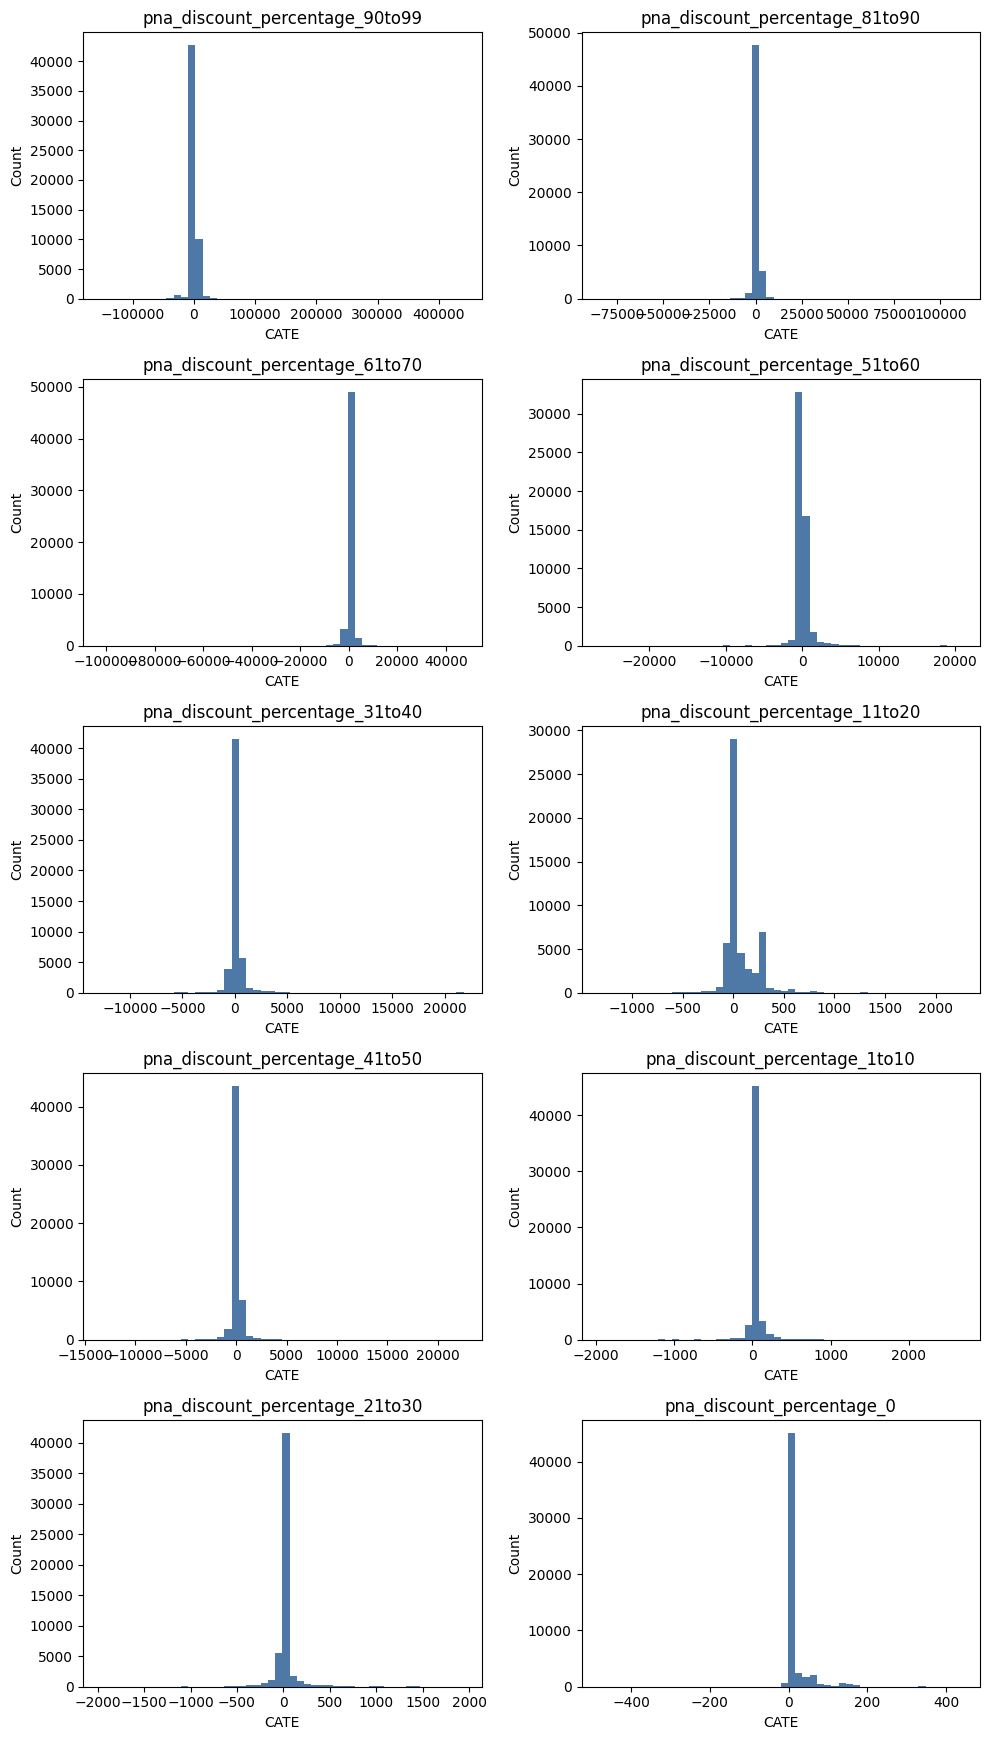

In [94]:


# Show top-N by |mean|
topN = 10
top_vars = (summary_df.assign(abs_mean=lambda d: d['mean'].abs())
                        .sort_values('abs_mean', ascending=False)
                        .head(topN)['variable']
                        .tolist())

print(f"Top {topN} variables by |mean CATE|:", top_vars)

# Plot histograms for the top variables
econ = results.get('econml', {}) or {}
ncols = 2
nrows = int(np.ceil(len(top_vars)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.5*nrows))
axes = np.atleast_1d(axes).ravel()

for ax, var in zip(axes, top_vars):
    cate = np.asarray(econ[var]['cate']).ravel()
    ax.hist(cate[~np.isnan(cate)], bins=50, color='#4e79a7')
    ax.set_title(var)
    ax.set_xlabel('CATE')
    ax.set_ylabel('Count')

for ax in axes[len(top_vars):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


Top 10 variables by |mean CATE|: ['pna_discount_percentage_90to99', 'pna_discount_percentage_81to90', 'pna_discount_percentage_61to70', 'pna_discount_percentage_51to60', 'pna_discount_percentage_31to40', 'pna_discount_percentage_11to20', 'pna_discount_percentage_41to50', 'pna_discount_percentage_1to10', 'pna_discount_percentage_21to30', 'pna_discount_percentage_0']


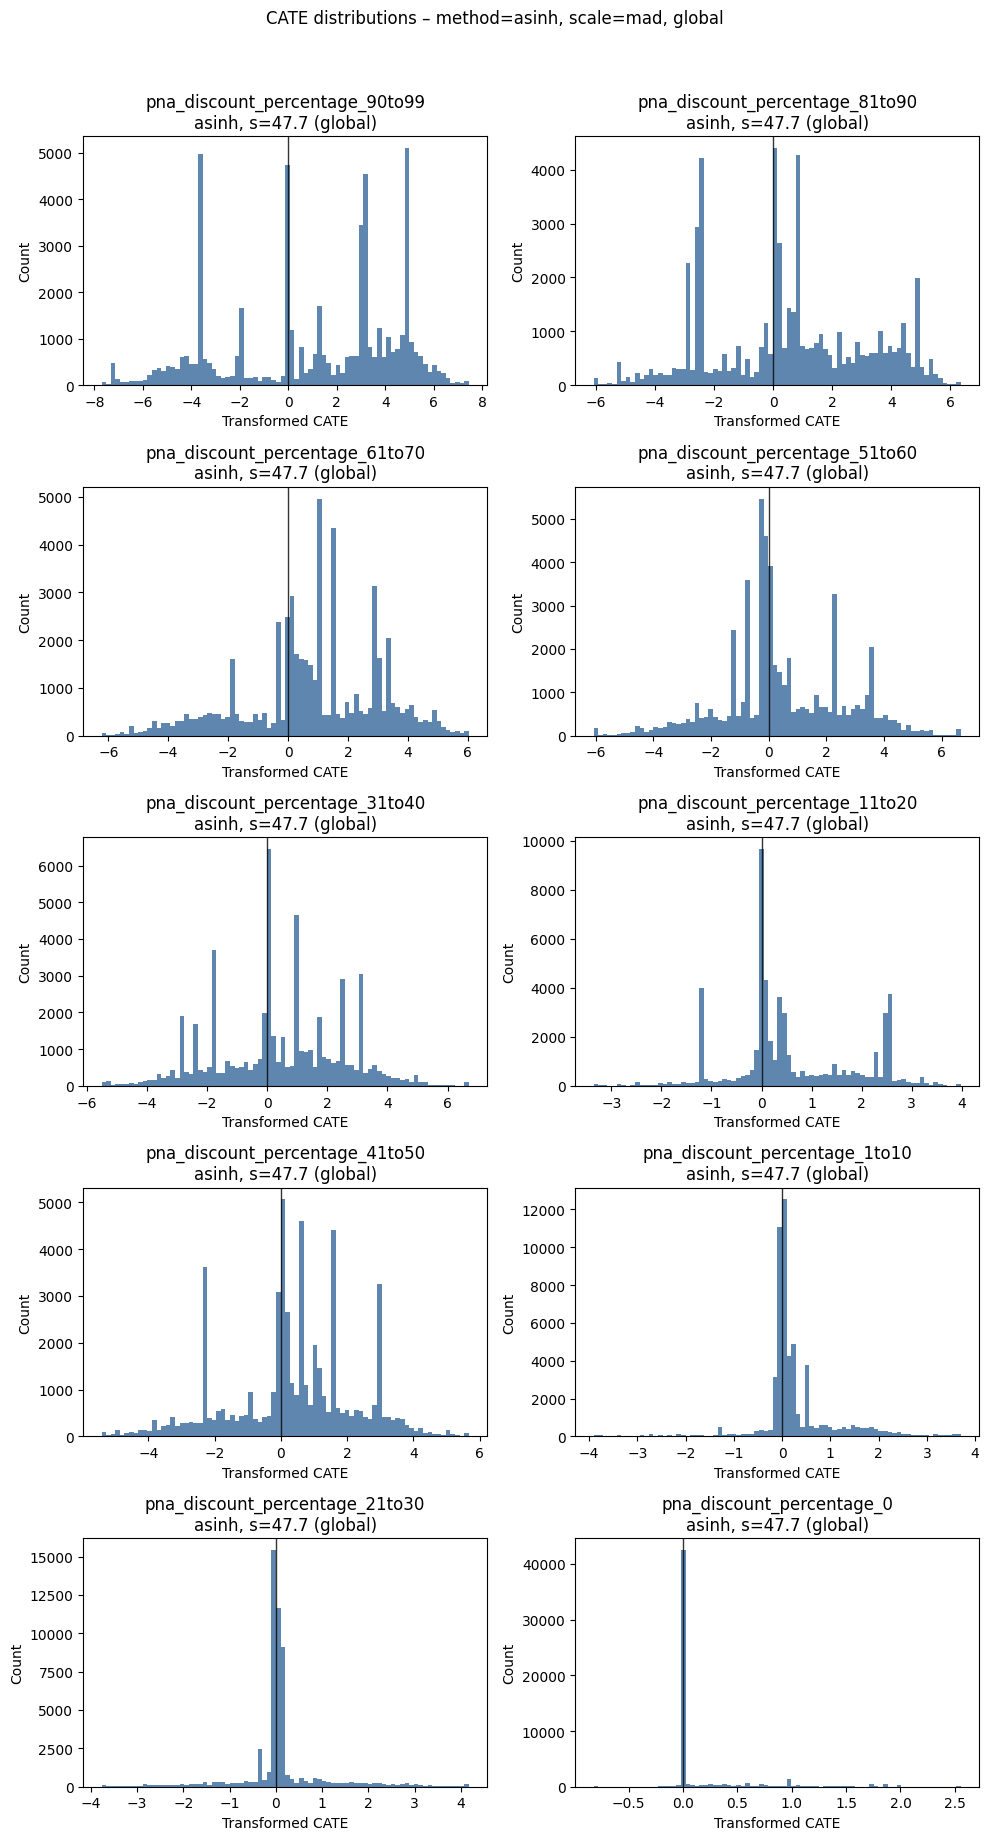

In [98]:
# --- Utilities ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

method = 'asinh'
scale = 'mad'
use_global_scale = True
clip_pct = 0.1


method = 'symlog'
symlog_linthresh = 10  # widen/narrow the linear window around 0

method = 'yeojohnson'
use_global_scale = False  # not used for yeojohnson anyway


def mad(x):
    """Median Absolute Deviation (robust scale)."""
    x = np.asarray(x)
    med = np.nanmedian(x)
    m = np.nanmedian(np.abs(x - med))
    return m if m not in (None, 0) else 1.0

def transform_array(x, method='asinh', scale='mad', global_scale=None, symlog_linthresh=10):
    """
    Apply a transform to handle heavy tails while keeping sign & zero visible.

    method: 'none' | 'symlog' | 'signed_log1p' | 'asinh' | 'yeojohnson'
    scale:  'mad' | 'iqr' | float (only for signed_log1p/asinh)
    global_scale: None or float; if provided, overrides computed scale.
    """
    x = np.asarray(x).ravel()
    mask = np.isfinite(x)
    out = x.copy()

    if method == 'none':
        return out, {}

    if method == 'symlog':
        # No data transform; axis scaling will be applied in the plot
        return out, {'symlog_linthresh': symlog_linthresh}

    # Determine scale parameter s for tails (only for signed_log1p / asinh)
    if method in ('signed_log1p', 'asinh'):
        if global_scale is not None:
            s = float(global_scale) if global_scale != 0 else 1.0
        else:
            if scale == 'mad':
                s = mad(x[mask])
            elif scale == 'iqr':
                q1, q3 = np.nanpercentile(x, [25, 75])
                s = (q3 - q1) / 2.0
                s = s if s not in (None, 0) else 1.0
            elif isinstance(scale, (int, float)):
                s = float(scale) if scale != 0 else 1.0
            else:
                s = 1.0

    if method == 'signed_log1p':
        out[mask] = np.sign(x[mask]) * np.log1p(np.abs(x[mask]) / s)
        return out, {'s': s}

    if method == 'asinh':
        out[mask] = np.arcsinh(x[mask] / s)
        return out, {'s': s}

    if method == 'yeojohnson':
        # Learns a power transform that tends to Gaussianize (handles negatives)
        pt = PowerTransformer(method='yeo-johnson', standardize=True)
        out[mask] = pt.fit_transform(x[mask].reshape(-1,1)).ravel()
        lam = getattr(pt, 'lambdas_', [None])[0]
        return out, {'lambda_': lam}

    return out, {}

# --- Your original "Top-N by |mean|" selection ---
topN = 10
top_vars = (summary_df.assign(abs_mean=lambda d: d['mean'].abs())
                        .sort_values('abs_mean', ascending=False)
                        .head(topN)['variable']
                        .tolist())

print(f"Top {topN} variables by |mean CATE|:", top_vars)

# --- Parameters for transforms ---
method = 'asinh'          # 'none' | 'symlog' | 'signed_log1p' | 'asinh' | 'yeojohnson'
scale = 'mad'             # 'mad' | 'iqr' | float   (used by 'signed_log1p'/'asinh')
use_global_scale = True   # Use one global scale across variables for comparability
clip_pct = 0.1            # None or (e.g.) 0.1 to clip tails at 0.1% on each side (visualization only)
bins = 80
ncols = 2
symlog_linthresh = 10     # Only used for method='symlog'

# --- Plot histograms for the top variables with transform ---
econ = results.get('econml', {}) or {}

# Compute an optional global scale across selected variables (for signed_log1p/asinh)
global_scale = None
if method in ('signed_log1p', 'asinh') and use_global_scale:
    pooled = np.concatenate([np.asarray(econ[v]['cate']).ravel() for v in top_vars])
    pooled = pooled[np.isfinite(pooled)]
    global_scale = mad(pooled) if scale == 'mad' else None
    # If you set scale='iqr', you could compute a pooled IQR here similarly.

nrows = int(np.ceil(len(top_vars)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.6*nrows))
axes = np.atleast_1d(axes).ravel()

for ax, var in zip(axes, top_vars):
    cate = np.asarray(econ[var]['cate']).ravel()
    x = cate.copy()

    # Optional clipping to tame extreme tails visually (does not change data persistently)
    if clip_pct is not None:
        lo, hi = np.nanpercentile(x, [clip_pct, 100-clip_pct])
        x = np.clip(x, lo, hi)

    # Transform
    x_t, info = transform_array(
        x,
        method=method,
        scale=scale,
        global_scale=global_scale,
        symlog_linthresh=symlog_linthresh
    )

    # Plot
    ax.hist(x_t[np.isfinite(x_t)], bins=bins, color='#4e79a7', alpha=0.9)
    ax.axvline(0, color='k', lw=1, alpha=0.8)

    # Apply symlog axis if chosen
    if method == 'symlog':
        ax.set_xscale('symlog', linthresh=symlog_linthresh, linscale=1.0)
        ax.set_xlabel(f"CATE (symlog, linthresh={symlog_linthresh})")
    else:
        ax.set_xlabel("Transformed CATE" if method != 'none' else "CATE")

    # Title with transform info
    subtitle = ""
    if method in ('signed_log1p', 'asinh'):
        s = info.get('s', None)
        if s is not None:
            subtitle = f"\n{method}, s={s:.3g}{' (global)' if use_global_scale else ''}"
    elif method == 'yeojohnson':
        lam = info.get('lambda_', None)
        subtitle = f"\nYeo-Johnson{'' if lam is None else f', λ={lam:.3g}'}"
    elif method == 'symlog':
        subtitle = "\nsymlog axis"

    ax.set_title(f"{var}{subtitle}")
    ax.set_ylabel("Count")

# Hide any unused axes
for ax in axes[len(top_vars):]:
    ax.axis('off')

fig.suptitle(f"CATE distributions – method={method}, scale={scale}, "
             f"{'global' if (method in ('signed_log1p','asinh') and use_global_scale) else 'per-variable'}",
             y=1.02, fontsize=12)
fig.tight_layout()
plt.show()


In [ ]:
method = 'asinh'
scale = 'mad'
use_global_scale = True
clip_pct = 0.1
